## Ejercicio 6: Correlación de NDVI y NDWI con la cianobacteria

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src.config import LAGOS

sys.path.append("..")
plt.rcParams["figure.dpi"] = 100


### 6.a Correlación agregada (por fecha)

In [4]:
tabla = pd.read_csv("../data/processed/tabla_temporal.csv", parse_dates=["fecha"])

filas = []
for lago, g in tabla.groupby("lago"):
    for var in ["ndvi", "ndwi"]:
        r, p_r = stats.pearsonr(g[var], g["cianobacteria"])
        rho, p_rho = stats.spearmanr(g[var], g["cianobacteria"])
        filas.append({"lago": lago, "variable": var, "pearson_r": r, "pearson_p": p_r,
                       "spearman_rho": rho, "spearman_p": p_rho, "n": len(g)})

corr_tabla = pd.DataFrame(filas)
print(corr_tabla)

        lago variable  pearson_r  pearson_p  spearman_rho  spearman_p   n
0  amatitlan     ndvi  -0.019063   0.955636      0.100000    0.769875  11
1  amatitlan     ndwi   0.409499   0.211045      0.336364    0.311824  11
2    atitlan     ndvi  -0.241148   0.475021     -0.672727    0.023313  11
3    atitlan     ndwi  -0.774027   0.005175     -0.590909    0.055576  11


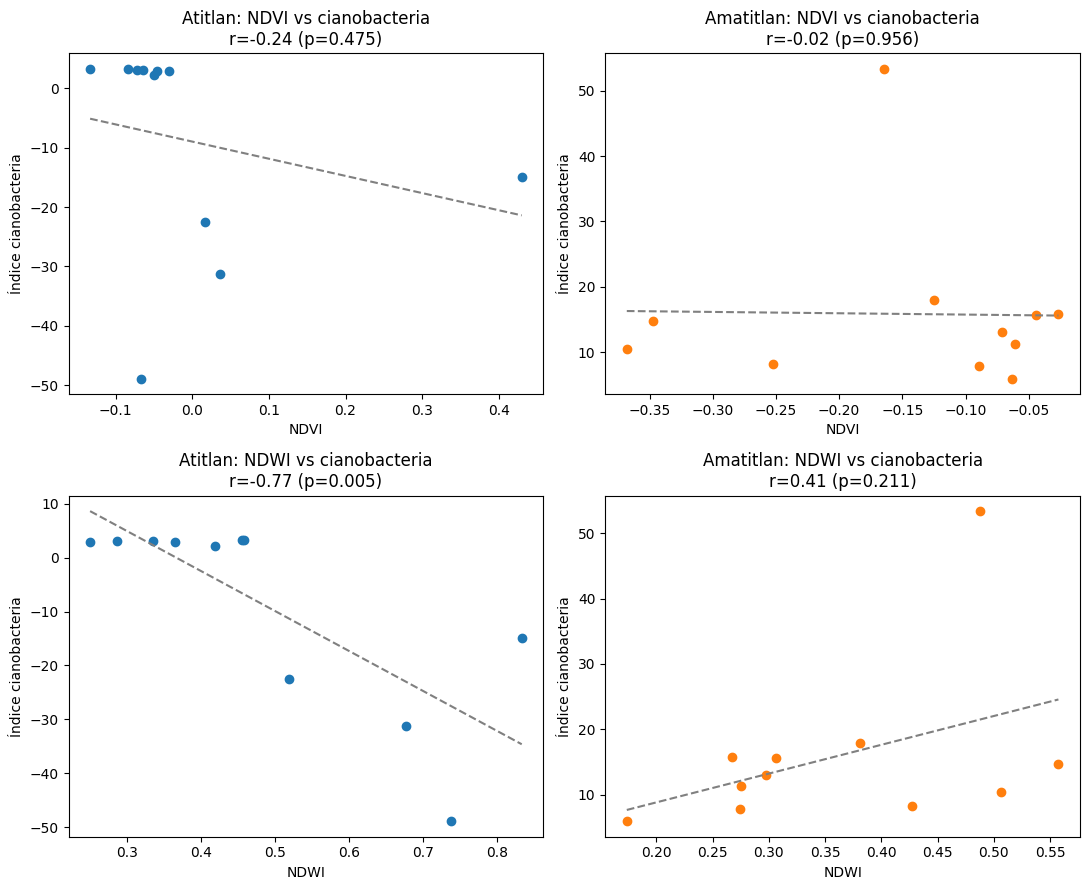

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
variables = ["ndvi", "ndwi"]
lagos = ["atitlan", "amatitlan"]

for i, var in enumerate(variables):
    for j, lago in enumerate(lagos):
        ax = axes[i, j]
        g = tabla[tabla["lago"] == lago]
        ax.scatter(g[var], g["cianobacteria"], color="tab:blue" if lago == "atitlan" else "tab:orange")
        m, b = np.polyfit(g[var], g["cianobacteria"], 1)
        xs = np.linspace(g[var].min(), g[var].max(), 50)
        ax.plot(xs, m * xs + b, "--", color="gray")
        fila = corr_tabla[(corr_tabla["lago"] == lago) & (corr_tabla["variable"] == var)].iloc[0]
        ax.set_title(f"{lago.capitalize()}: {var.upper()} vs cianobacteria\nr={fila.pearson_r:.2f} (p={fila.pearson_p:.3f})")
        ax.set_xlabel(var.upper())
        ax.set_ylabel("Índice cianobacteria")

plt.tight_layout()
plt.show()

**Hallazgos principales**

Al analizar las 11 fechas disponibles para cada lago, se encontraron diferencias importantes entre Atitlán y Amatitlán.

* **Atitlán:** se observa una relación negativa fuerte entre el NDWI y el índice de cianobacteria (Pearson r ≈ −0.77, p ≈ 0.005). La correlación de Spearman también es negativa, aunque algo más moderada (ρ ≈ −0.59, p ≈ 0.056). Por su parte, el NDVI presenta una relación negativa moderada con la cianobacteria, estadísticamente significativa según Spearman (ρ ≈ −0.67, p ≈ 0.023). En términos generales, esto indica que las fechas con valores más altos de NDWI, asociados a una mayor señal de agua y a condiciones ópticas características de aguas profundas y transparentes, tienden a presentar menores valores del índice de cianobacteria. Este comportamiento es consistente con las características de Atitlán como un lago profundo y oligotrófico, donde durante el período analizado se observó una baja proliferación de algas.

* **Amatitlán:** no se encontraron correlaciones estadísticamente significativas entre los índices analizados y la cianobacteria. La relación con NDVI es prácticamente nula (r ≈ −0.02, p ≈ 0.96), mientras que con NDWI es positiva, pero débil y no significativa (r ≈ 0.41, p ≈ 0.21). 

**Interpretación ambiental**
En Atitlán, el NDWI muestra un comportamiento que podría utilizarse como indicador indirecto de condiciones del agua asociadas con menores niveles de cianobacteria. En cambio, para Amatitlán no existe evidencia suficiente para establecer una relación clara entre estos índices y la presencia de cianobacteria. Por lo tanto, estos resultados deben considerarse como una primera aproximación.

### 6.b Correlación a nivel de píxel (opcional — requiere `data/raw/`)

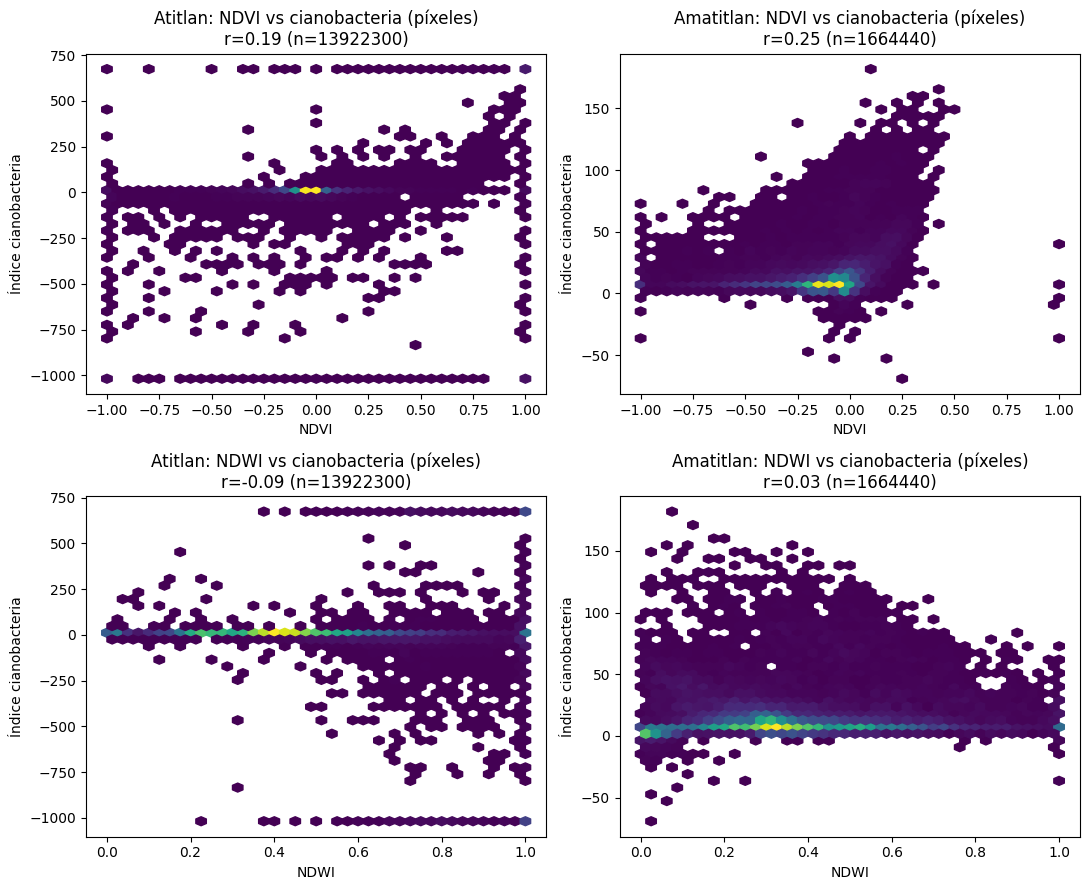

,lago,variable,pearson_r,pearson_p,n_pixeles
0,atitlan,ndvi,0.186155,0.0,13922300
1,atitlan,ndwi,-0.091177,0.0,13922300
2,amatitlan,ndvi,0.253049,0.0,1664440
3,amatitlan,ndwi,0.034479,0.0,1664440


In [6]:
from src.download import DATA_RAW
from src.indices import compute_indices
from src.mask import get_water_mask

MUESTRA_MAX = 20000  # limita puntos por lago para que el scatter no sea ilegible / lento

pixeles = {"atitlan": {"ndvi": [], "ndwi": [], "cianobacteria": []},
           "amatitlan": {"ndvi": [], "ndwi": [], "cianobacteria": []}}

for lago, datos in LAGOS.items():
    for fecha in datos["fechas"]:
        tif_path = DATA_RAW / lago / f"{fecha}.tif"
        if not tif_path.exists():
            print(f"Falta {tif_path}, se omite.")
            continue
        idx = compute_indices(lago, fecha)
        water = get_water_mask(lago, tif_path, idx["ndwi"])
        valid = water & ~np.isnan(idx["cianobacteria"]) & ~np.isnan(idx["ndvi"]) & ~np.isnan(idx["ndwi"])
        pixeles[lago]["ndvi"].append(idx["ndvi"][valid])
        pixeles[lago]["ndwi"].append(idx["ndwi"][valid])
        pixeles[lago]["cianobacteria"].append(idx["cianobacteria"][valid])

resultados_pixel = []
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
rng = np.random.default_rng(42)

for j, lago in enumerate(lagos):
    ndvi_all = np.concatenate(pixeles[lago]["ndvi"])
    ndwi_all = np.concatenate(pixeles[lago]["ndwi"])
    ciano_all = np.concatenate(pixeles[lago]["cianobacteria"])

    if len(ndvi_all) > MUESTRA_MAX:
        idx_muestra = rng.choice(len(ndvi_all), MUESTRA_MAX, replace=False)
        ndvi_p, ndwi_p, ciano_p = ndvi_all[idx_muestra], ndwi_all[idx_muestra], ciano_all[idx_muestra]
    else:
        ndvi_p, ndwi_p, ciano_p = ndvi_all, ndwi_all, ciano_all

    for i, (var, arr) in enumerate([("ndvi", ndvi_all), ("ndwi", ndwi_all)]):
        r, p = stats.pearsonr(arr, ciano_all)
        resultados_pixel.append({"lago": lago, "variable": var, "pearson_r": r, "pearson_p": p, "n_pixeles": len(arr)})
        arr_p = ndvi_p if var == "ndvi" else ndwi_p
        ax = axes[i, j]
        ax.hexbin(arr_p, ciano_p, gridsize=40, cmap="viridis", mincnt=1)
        ax.set_title(f"{lago.capitalize()}: {var.upper()} vs cianobacteria (píxeles)\nr={r:.2f} (n={len(arr)})")
        ax.set_xlabel(var.upper())
        ax.set_ylabel("Índice cianobacteria")

plt.tight_layout()
plt.show()

pd.DataFrame(resultados_pixel)


**Correlación a nivel de píxel**

El análisis a nivel de píxel muestra que las relaciones entre NDVI, NDWI y la presencia de cianobacteria son, en general, débiles. En Atitlán, el NDVI presenta una correlación positiva débil (r ≈ 0.19), mientras que el NDWI presenta una correlación negativa muy débil (r ≈ −0.09). En Amatitlán, ambas relaciones son positivas y débiles: NDVI (r ≈ 0.25) y NDWI (r ≈ 0.03).

Estos resultados sugieren que, a nivel espacial, ninguno de los dos índices presenta una relación suficientemente fuerte con la presencia de cianobacteria como para considerarlo un indicador directo de su distribución dentro del lago. La diferencia respecto al análisis agregado también indica que algunas relaciones observadas al trabajar con promedios por fecha pueden estar asociadas a variaciones temporales entre imágenes y no necesariamente a patrones espaciales dentro de cada lago.

Desde el punto de vista ambiental, la baja magnitud de las correlaciones indica que la presencia de cianobacteria probablemente depende de otros factores que no son capturados directamente por NDVI y NDWI, como nutrientes, temperatura, profundidad, condiciones de mezcla del agua y disponibilidad de luz.

Asimismo, se identificaron algunos valores extremos en los índices, particularmente en el índice de cianobacteria. Estos valores pueden corresponder a píxeles afectados por nubes, sombras, bordes de imagen u otros problemas de enmascaramiento, y podrían influir en la magnitud de las correlaciones. 